# Does a higher top-20 score mean a better content queue?

**Lane 2 — Refresh / Content Opportunity Scoring.** This executable companion mirrors the nine-section public paper. It reruns the frozen pipeline, writes aggregate receipts, regenerates the historical local queue and builds the static paper. Reproduction does not retune the model after June.

**Five-sentence abstract:** Can a small search-data model help an editor choose pages to inspect for a possible refresh? We trained on 14,137 March pages from 24 clients and tested later outcomes from untrained clients. A frozen depth-three tree used five past-window features and competed with a volume-only rule on the same eligibility and decline proxy. On 35,588 June pages across six held-out clients, it found 17 declines in its top twenty versus 15 for the baseline, but lost within every client with more than twenty eligible pages. The result supports a guarded historical inspection exercise, while broad deployment and refresh-benefit claims remain unsupported.

## 1. Question and decision

Does a simple learned ranking improve a twenty-slot content-review queue over a transparent exposure rule, and does any improvement hold within clients? The owner is an editor; the action is inspection before deciding whether content needs a refresh. A false positive wastes a slot or prompts an unnecessary edit; a false negative delays attention. The model estimates a traffic-decline proxy, not the effect of editing.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "skills/README.md").exists())
sys.path.insert(0, str(ROOT / "work/scripts"))
import capstone_pipeline as cp
SUMMARY_PATH = ROOT / "work/outputs/capstone_metrics.json"
if not SUMMARY_PATH.exists():
    cp.execute()
s = json.loads(SUMMARY_PATH.read_text())
print("Dataset revision:", s["dataset_revision"])
print("Protocol:", s["protocol_version"], s["protocol_sha256"])

# Full rerun from pinned monthly data/caches; no hyperparameter selection.
s=cp.execute()
print("Historical decision date: 2026-06-17; primary metric: decline-proxy precision@20.")

/var/home/tanzimul/Repos/github.com/tanzimul3islam/flyrank-ml-internship-starter/work/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset revision: 50cbf7c3909d07be4d1b5906b4d09e882e5acbf2
Protocol: capstone_v1 181f2c24f2742facb0f37fdf77f1ab5727a2b5cfa5876477fe235e63117e437f
Build March frame and verify frozen baseline split.


March method fixed. Read final June partition; no tuning after this point.


{
  "march": {
    "baseline": {
      "n": 43487,
      "clients": 8,
      "base_rate": 0.37436475268471037,
      "k": 20,
      "top_k_declines": 9,
      "precision_at_k": 0.45,
      "roc_auc": 0.5324104424997577,
      "average_precision": 0.398071706991129,
      "top_k_clients": 3
    },
    "model": {
      "n": 43487,
      "clients": 8,
      "base_rate": 0.37436475268471037,
      "k": 20,
      "top_k_declines": 14,
      "precision_at_k": 0.7,
      "roc_auc": 0.6037728244890004,
      "average_precision": 0.44568691225097606,
      "top_k_clients": 2
    }
  },
  "june_primary": {
    "baseline": {
      "n": 35588,
      "clients": 6,
      "base_rate": 0.5889625716533663,
      "k": 20,
      "top_k_declines": 15,
      "precision_at_k": 0.75,
      "roc_auc": 0.5989326665816055,
      "average_precision": 0.6353563969363651,
      "top_k_clients": 4
    },
    "model": {
      "n": 35588,
      "clients": 6,
      "base_rate": 0.5889625716533663,
      "k": 20,
     

Historical decision date: 2026-06-17; primary metric: decline-proxy precision@20.


## 2. Data

Use only March and June partitions of the pinned FlyRank warehouse release. One source row is a page-day and one scored row is a page at a decision date. Features cover days 1–14; days 15–16 are a reporting buffer; outcomes cover days 17–30. Require GSC availability IS TRUE, valid counts, complete fourteen-day past coverage and at least 100 past impressions. Complete later coverage is needed only to observe the label.

The June grain check stopped before scoring. Exactly 6,390 identical duplicate copies were removed under a committed data-only amendment; conflicts would still fail. Daily position below 1 is treated as missing, following Week 4's review. Private identities, URLs, queries, product flags and overlapping query-table data are excluded.

In [2]:
display(pd.DataFrame([s["march_source"],s["june_source"]]))
display(pd.DataFrame({"cohort":["March training","March reused comparison","June final client cohort"],
    "pages":[s["train_pages"],s["march_comparison_pages"],s["june_primary"]["model"]["n"]],
    "clients":[s["train_clients"],s["march_comparison_clients"],s["june_primary"]["model"]["clients"]]}))

,source_rows,first_date,last_date,clients,gsc_available_rows,gsc_false_rows,gsc_null_rows,subone_position_rows,duplicate_keys,identical_extra_rows_removed,conflicting_keys,clean_page_day_rows,partition,source_grain_violations_before_cleaning,source_grain_violations_after_cleaning,aggregate_rows
0,9841378,2026-03-01,2026-03-31,55,3611061,6230317,0,101548,0,0,0,9841378,fact_content_daily_performance/month=2026-03/d...,0,0,176738
1,11694072,2026-06-01,2026-06-30,65,3878937,7815135,0,38010,6390,6390,0,11687682,fact_content_daily_performance/month=2026-06/d...,6390,0,208636


,cohort,pages,clients
0,March training,14137,24
1,March reused comparison,43487,8
2,June final client cohort,35588,6


## 3. Methodology

The frozen tree has depth 3, minimum leaf size 100, and seed 42. Its inputs are past exposure, CTR, impression-weighted position, active-day share and daily variability. A train-only median imputer handles missing positions. The proxy is later impressions <80% of past impressions. The baseline remains Week 4's volume-first rule.

Five-fold client-grouped validation uses March development clients. The reused March comparison is reported transparently. June's primary test uses the same held-out client identities at a later date; no June outcomes inform fitting or selection. A paired client bootstrap, per-client rankings and secondary all-client June evaluation qualify the pooled result. Source code and the pre-June protocol commit make this boundary auditable.

In [3]:
display(json.loads((ROOT/"work/capstone_protocol.json").read_text()))
assert all(s["checks"].values())
display(pd.DataFrame(s["feature_summary"]))
print((ROOT/"work/outputs/capstone_tree.txt").read_text())

{'protocol_version': 'capstone_v1',
 'dataset_revision': '50cbf7c3909d07be4d1b5906b4d09e882e5acbf2',
 'lane': 'Refresh / Content Opportunity Scoring',
 'development_month': '2026-03',
 'final_month': '2026-06',
 'feature_days': [1, 14],
 'buffer_days': [15, 16],
 'decision_day': 17,
 'outcome_days': [17, 30],
 'minimum_past_impressions': 100,
 'coverage': '14 valid GSC days per window; future coverage for label only',
 'label': 'outcome_impressions < 0.8 * past_impressions',
 'features': ['mean_daily_impressions',
  'ctr_pct',
  'impression_weighted_position',
  'active_day_share',
  'daily_impression_cv'],
 'quality_change': 'Daily position <1 becomes missing, motivated by Week 4 review before June was read; row eligibility unchanged.',
 'model': {'class': 'DecisionTreeClassifier',
  'max_depth': 3,
  'min_samples_leaf': 100,
  'random_state': 42},
 'missing_values': 'Median imputation fitted only on March development clients; no extra features',
 'split': {'class': 'GroupShuffleSplit

,feature,train_median,final_median,train_missing_fraction,final_missing_fraction
0,mean_daily_impressions,35.928571,38.857143,0.000000,0.0
1,ctr_pct,0.196592,0.255346,0.000000,0.0
2,impression_weighted_position,8.797459,9.222756,0.000354,0.0
3,active_day_share,1.000000,1.000000,0.000000,0.0
4,daily_impression_cv,0.425062,0.391861,0.000000,0.0


|--- ctr_pct <= 0.361
|   |--- mean_daily_impressions <= 17.036
|   |   |--- mean_daily_impressions <= 12.179
|   |   |   |--- class: 0
|   |   |--- mean_daily_impressions >  12.179
|   |   |   |--- class: 0
|   |--- mean_daily_impressions >  17.036
|   |   |--- impression_weighted_position <= 26.338
|   |   |   |--- class: 0
|   |   |--- impression_weighted_position >  26.338
|   |   |   |--- class: 1
|--- ctr_pct >  0.361
|   |--- ctr_pct <= 0.376
|   |   |--- daily_impression_cv <= 0.544
|   |   |   |--- class: 0
|   |   |--- daily_impression_cv >  0.544
|   |   |   |--- class: 0
|   |--- ctr_pct >  0.376
|   |   |--- daily_impression_cv <= 0.370
|   |   |   |--- class: 0
|   |   |--- daily_impression_cv >  0.370
|   |   |   |--- class: 0



## 4. Results against the baseline

The final pooled result is 85% precision@20 versus 75%, with 58.90% decline prevalence. Yet the model's AUC is lower (0.575 vs 0.599) and it ranks worse inside every client with more than twenty pages. The all-client June comparison also favors the baseline at top twenty. The -60 to +20 percentage-point client-bootstrap interval is wide; this is a qualified finding, not an established operational win.

In [4]:
rows=[]
for cohort in ["march_comparison","june_primary","june_secondary_all_clients"]:
    for name,result in s[cohort].items():rows.append({"cohort":cohort,"method":name,**result})
display(pd.DataFrame(rows))
display(pd.DataFrame(s["per_client_primary"]))
display(pd.DataFrame([s["bootstrap"]]))

,cohort,method,n,clients,base_rate,k,top_k_declines,precision_at_k,roc_auc,average_precision,top_k_clients
0,march_comparison,baseline,43487,8,0.374365,20,9,0.45,0.532410,0.398072,3
1,march_comparison,model,43487,8,0.374365,20,14,0.70,0.603773,0.445687,2
2,june_primary,baseline,35588,6,0.588963,20,15,0.75,0.598933,0.635356,4
3,june_primary,model,35588,6,0.588963,20,17,0.85,0.575267,0.639196,2
4,june_secondary_all_clients,baseline,64818,42,0.502900,20,17,0.85,0.584050,0.547044,7
5,june_secondary_all_clients,model,64818,42,0.502900,20,16,0.80,0.578351,0.558043,2


,anonymous_client,n,k,base_rate,baseline_p_at_k,model_p_at_k
0,Group 1,109,20,0.688073,0.900000,0.750000
1,Group 2,9695,20,0.683858,0.950000,0.850000
2,Group 3,8930,20,0.541769,0.650000,0.200000
3,Group 4,14579,20,0.546883,0.600000,0.250000
4,Group 5,17,17,0.470588,0.470588,0.470588
5,Group 6,2258,20,0.635961,0.550000,0.400000


,method,resamples,clusters,lift_interval_95,caution
0,paired client bootstrap; rerank global top20; ...,500,6,"[-0.6000000000000001, 0.19999999999999996]",Descriptive percentile interval with few clien...


## 5. Limitations and honest framing

Visibility decline is not refresh benefit. Six final client clusters, retrospective coverage selection, missing ingestion timestamps, tied leaf scores, uninspected page context and one later month limit the claim. Historical June recommendations are not current content instructions. Broad deployment is not justified by the global metric gain because the client-level audit is adverse.

In [5]:
print("June unknown outcomes retained in queue:",s["june_primary_unlabeled_pages"])
g=pd.DataFrame(s["per_client_primary"])
rankable=g[g.n>g.k]
assert (rankable.model_p_at_k < rankable.baseline_p_at_k).all()
print("Rankable clients with worse model precision:",len(rankable))

June unknown outcomes retained in queue: 3808
Rankable clients with worse model precision: 5


## 6. Ranked recommendations

Show the ten highest-ranked historical review slots from the selected model illustration. Full pseudonymous keys remain only in the ignored CSV; public slots omit raw measurements and identifiers. Every action is inspection before editing, with low editorial confidence. Keep the baseline as the operational reference until a prospectively evaluated client-allocation policy and independent editorial judgments justify a change.

In [6]:
display(pd.DataFrame(s["public_recommendations"])[["rank","candidate","action","reason_code","wrong_if","confidence"]])
print("Historical full queue rows:",s["historical_queue_rows"])

,rank,candidate,action,reason_code,wrong_if,confidence
0,1,Review 01,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
1,2,Review 02,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
2,3,Review 03,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
3,4,Review 04,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
4,5,Review 05,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
5,6,Review 06,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
6,7,Review 07,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
7,8,Review 08,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
8,9,Review 09,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...
9,10,Review 10,Inspect before refreshing,inspect_visibility_context,"The page already meets intent, or visibility l...",Low editorial confidence; page text and query ...


Historical full queue rows: 39396


## 7. Paper artifacts and reproducibility

The build script produces the nine required sections, three reproducible charts and a machine-readable publication fingerprint. Install `work/requirements-capstone.txt`, authenticate to the gated warehouse, run `python work/scripts/capstone_pipeline.py`, then `python work/scripts/build_research_paper.py` and the notebook runner. The repo includes pinned source revision, seeds, protocol, amendment, code and aggregate receipts.

Built nine-section paper, three charts (SVG/PNG), report, and publication fingerprint.


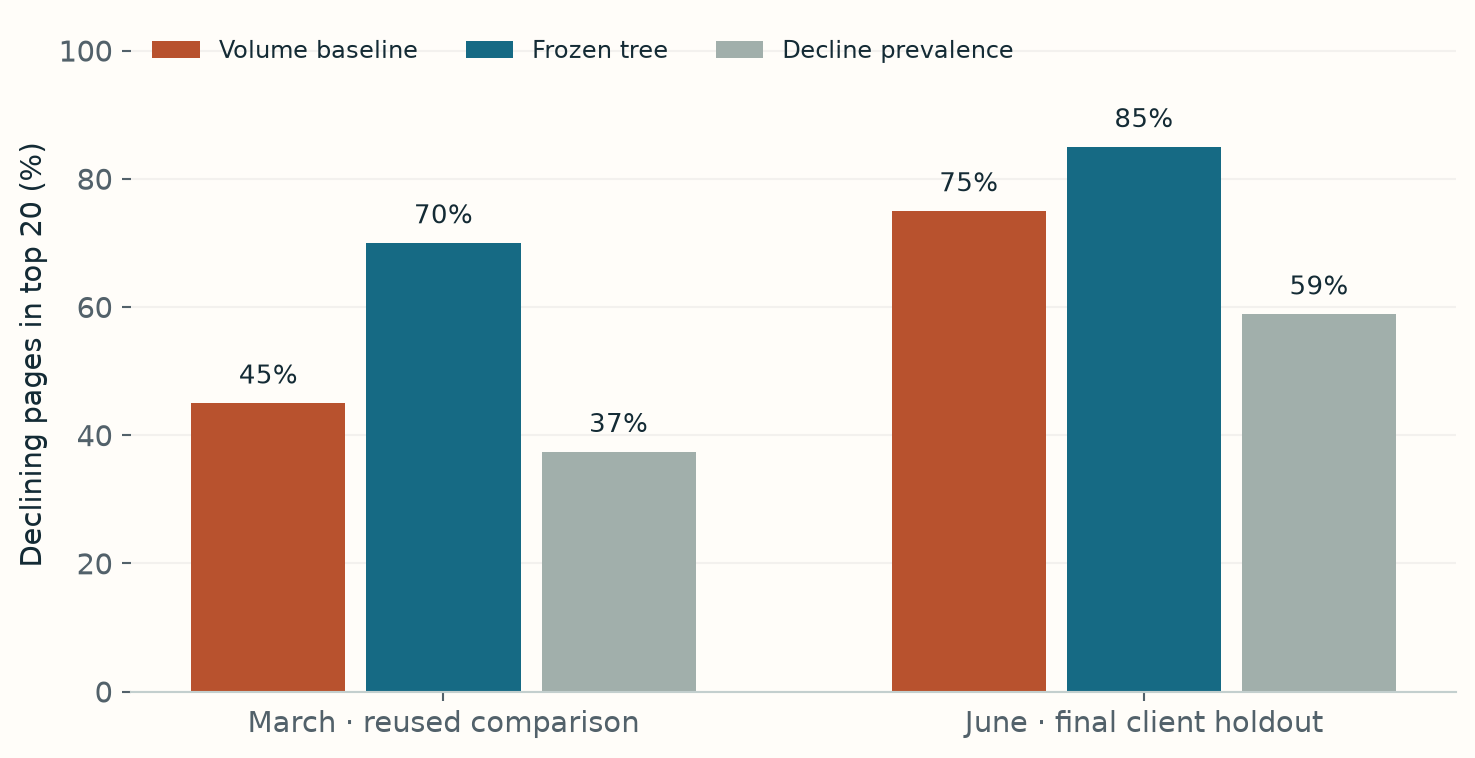

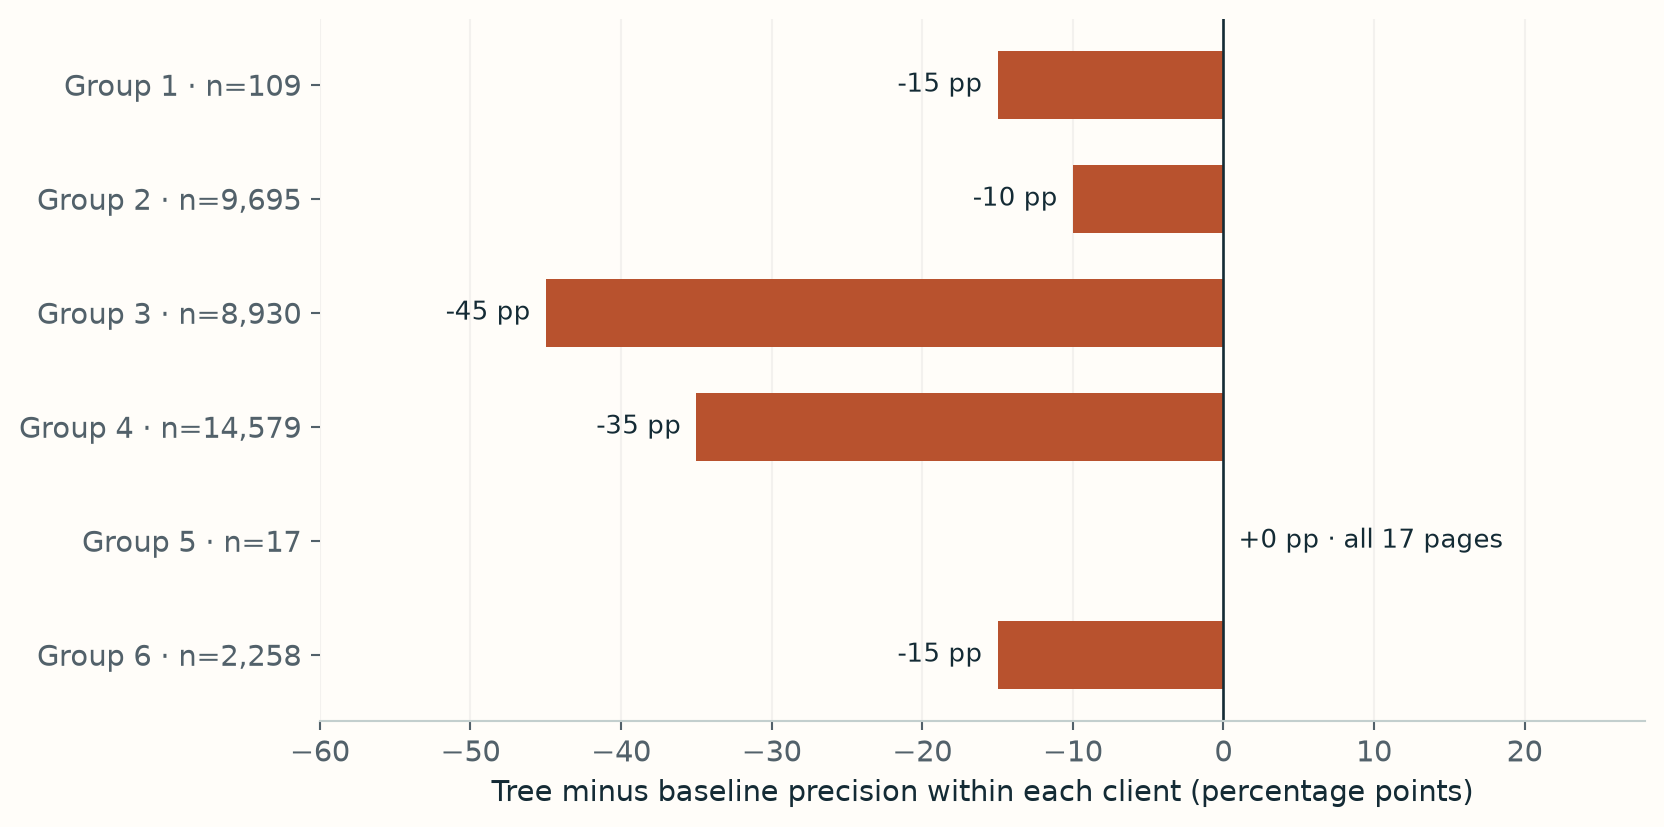

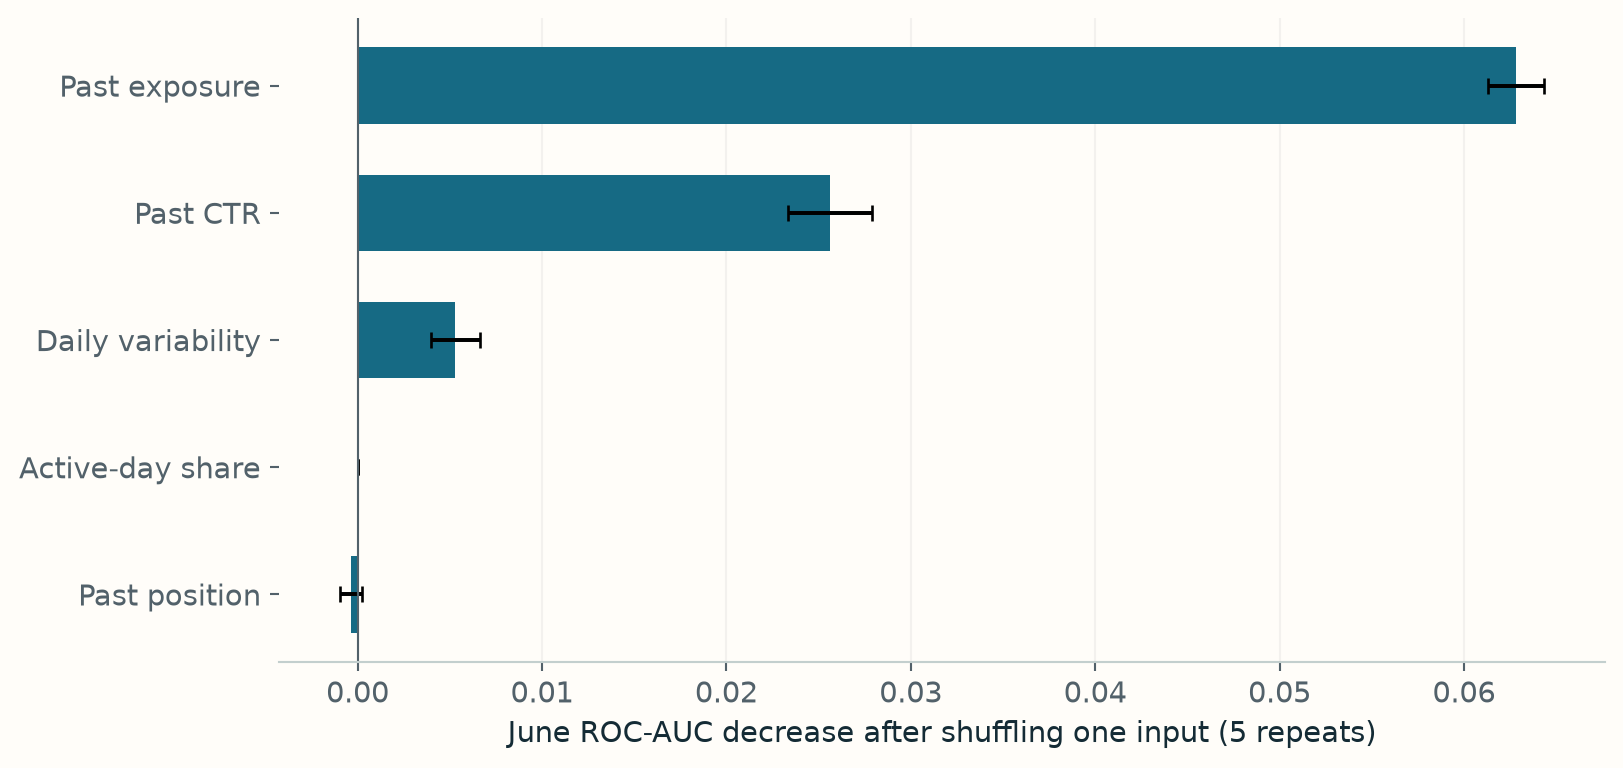

{'title': 'Does a higher top-20 score mean a better content queue?',
 'protocol_sha256': '181f2c24f2742facb0f37fdf77f1ab5727a2b5cfa5876477fe235e63117e437f',
 'metrics_sha256': '1133229f53b1fb7b5ec3504a484700ab9f9419ff97aa59b82a477cb272da469b',
 'required_sections': 9}

In [7]:
from build_research_paper import build
publication=build()
for name in ["top20-comparison","client-level-lift","feature-interpretation"]:
    display(Image(filename=str(ROOT/"work/figures"/(name+".png"))))
display(publication)

## 8. Acknowledgments & data credit

[Built on the FlyRank ML Internship dataset](https://flyrank.ai).

Thanks to the internship team for the release and starter materials. AI assistance supported code, checks, charts and drafting. No independent human content review or causal refresh experiment is claimed.

## 9. Demo and audience summaries

**Five-minute demo:** 0:00–0:45 explain the editor's twenty-slot decision; 0:45–1:30 show the two date windows and grouped split; 1:30–2:30 compare the frozen baseline and tree; 2:30–3:30 reveal the adverse client-level audit and uncertainty; 3:30–4:30 walk through one historical recommendation and its wrong-if condition; 4:30–5:00 open the reproducibility links and state what the work cannot claim.

**Social-post cut:** A global metric can hide worse client-level recommendations. My frozen FlyRank search-data tree found 17 declines in a June top twenty versus a volume rule's 15—but ranked worse within every rankable client. The public paper shows the grouped/time-separated method, uncertainty and complete code; no refresh-benefit claim. Share the verified URL from `submission/paper_url.txt` once deployed.

**Employer summary:** I built a reproducible search-content inspection pipeline on real FlyRank warehouse data, including a frozen baseline, a small tree and a public research paper. I trained on 14,137 March pages from 24 clients and evaluated a later 35,588-page cohort from six untrained clients. The analysis exposed a global top-twenty gain that failed client-level checks, demonstrating why operational validation matters more than one favorable headline metric.

## 10. Self-check

- [x] Repeatable real-data pipeline, frozen baseline, grouped and later-window evaluation.
- [x] Results, uncertainty, adverse checks, ranked inspection playbook and reproducibility links.
- [x] Executed notebook outputs and three generated research charts.
- [x] Nine-section paper with five-sentence abstract and linked FlyRank credit.
- [x] Demo outline, social cut and three-sentence employer summary.
- [x] Public deployment verified and its exact URL written to `submission/paper_url.txt`.

The publishing script checks the deployed publication fingerprint before recording the mandatory URL. A local build alone is not a live publication.